<a href="https://colab.research.google.com/github/Dawood-Ali123/Pytorch_learning/blob/main/Pytorch_autoGrad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Autograd (automatic differentiation) in PyTorch is a system that automatically calculates gradients of tensors during computations. When we set `requires_grad=True`, PyTorch starts tracking all operations performed on that tensor and builds a computation graph. When we call `.backward()`, it applies the chain rule to compute how much each input (like weights and bias) affects the final output (loss). These gradients are stored in `.grad` and are used to update model parameters during training. In simple terms, Autograd removes the need to manually compute derivatives and allows neural networks to learn efficiently.
**bold text**





In [21]:
import torch

Example NO 1

In [37]:
#inputs
x=torch.tensor(6.7)#input feature
y=torch.tensor(0.0)#out put feature
w=torch.tensor(1.0,requires_grad=True)#weight
b=torch.tensor(0.0,requires_grad=True)#bias

In [38]:
print(w)
print(b)

tensor(1., requires_grad=True)
tensor(0., requires_grad=True)


In [39]:
z=w*x+b
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [40]:
y_pred=torch.sigmoid(z)
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [43]:
#Binary cross entropy
def binary_cross_entropy(prediction,target):
  epsilon=1e-8
  prediction=torch.clamp(prediction,epsilon,1-epsilon)
  return-(target*torch.log(prediction)+(1-target)*torch.log(1-prediction))

In [46]:
loss=binary_cross_entropy(y_pred,y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

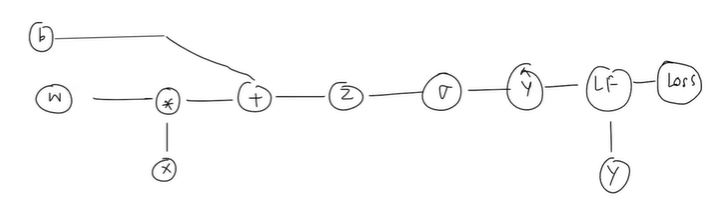

In [47]:
loss.backward()

In [48]:
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


Example NO 2

In [3]:
x=torch.tensor(3.0,requires_grad=True)

In [4]:
y=x**2

Here we have to find the derivatite internally irt makes the graph


In [5]:
print(x)
print(y)

tensor(3., requires_grad=True)
tensor(9., grad_fn=<PowBackward0>)


In [6]:
y.backward()

In [7]:
x.grad

tensor(6.)

Example no 3


In [9]:
x=torch.tensor(3.0,requires_grad=True)


In [11]:
y=x**2

In [12]:
z=torch.sin(y)

In [13]:
print(x)
print(y)
print(z)

tensor(3., requires_grad=True)
tensor(9., grad_fn=<PowBackward0>)
tensor(0.4121, grad_fn=<SinBackward0>)


In [14]:
z.backward()

In [15]:
x.grad

tensor(-5.4668)

 Example no 4 now we solve this using the vectors


In [50]:
x=torch.tensor([1.0,2.0,3.0],requires_grad=True)

In [52]:
y=(x**2).mean()
y

tensor(4.6667, grad_fn=<MeanBackward0>)

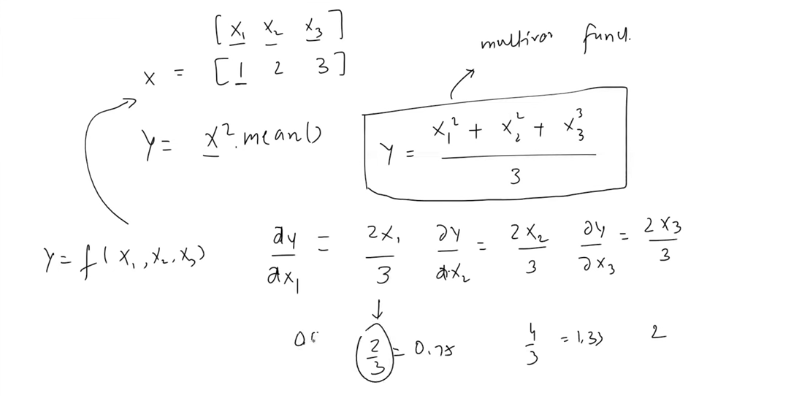

In [53]:
y.backward()

In [56]:
x.grad

tensor([0.6667, 1.3333, 2.0000])

Clearing the Grad


In [63]:
x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [72]:
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [73]:
y.backward()

In [74]:
x.grad

tensor(4.)

Here gradients are accumulating this is not desirable when we run the forward again and then the backward and the the x.grad it add the previuos gradient in it so due to this we cant get the  desire gradient so we have to add this new function x_grad.zero()

In [75]:
x.grad.zero_()

tensor(0.)

Gradient Tracking
  when we have completed our training and then we have to close the auto grad beacuse we cannot apply it during the prediction


In [82]:
x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [83]:
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [84]:
y.backward()

In [85]:
x.grad

tensor(4.)

In [77]:
#option1 _require_grad_(False)
#option2_detach()
#option3_torch.no_grad()


In [86]:
x.requires_grad_(False)
#here gradient tracking is stop

tensor(2.)

In [89]:
y=x**2
y
#here we cannot call the y_backward kun ky yaahn par ab gradient band ho chuki ha

tensor(4.)

Detach

In [90]:
x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [92]:
z=x.detach()
z
#now this is not the part of the computational graph

tensor(2.)

In [93]:
y=x**2
y

tensor(4., grad_fn=<PowBackward0>)

In [96]:
y1=z**2
y1

tensor(4.)

In [94]:
y.backward()

In [97]:
y1.backward()
#it cannot work here

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [95]:
x.grad

tensor(4.)

NO GRad


In [98]:
x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [100]:
with torch.no_grad():
  y=x**2

In [101]:
y.backward()

RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn